# Inkompressibles Neo-Hooke-Material: Taylor–Hood und MINI

Überführung des Benchmarks aus `../neo_hook_test/fenicsx_ed32_taylorhood_mini.py`.
Verglichen wird mit dem dort dokumentierten **ED32-Materialfit von Montanari et al. (Soft Matter, 2023)**. Die grauen experimentellen Kurven sind nicht als Rohdatentabelle vorhanden; die Referenzdaten hier sind Werte des veröffentlichten konstitutiven Fits.

## Modell und Referenz

Einheiten: mm, N und MPa. Probe: $15\times55\times3\,\mathrm{mm}^3$, Zug in $y$-Richtung; $\mu=0.405\,\mathrm{MPa}$ und Ogden-Exponent $\alpha=2$.

$$\Psi=\frac{\mu}{2}(I_1-3)-p(J-1),\qquad P=\mu F-p\,\operatorname{cof}F,\qquad J=1.$$

Für $\lambda=1+\varepsilon_\mathrm{nom}$ gilt
$$P_{22}=\mu(\lambda-\lambda^{-2}),\qquad p=\mu/\lambda.$$

Taylor–Hood verwendet $[P_2]^3/P_1$, MINI $[P_1+B_4]^3/P_1$ auf linearen Tetraedern. Beide kommen ohne künstliche Druckstabilisierung aus. Die homogene affine Lösung liegt in beiden Räumen; dieser Test prüft die Materialimplementierung, nicht das Verhalten bei inhomogener Deformation.

Randbedingungen: $u_y=0$ bei $y=0$, $u_y=\varepsilon_\mathrm{nom}55$ bei $y=55$, $u_x=0$ bei $x=0$ und $u_z=0$ bei $z=0$. Die gegenüberliegenden Seitenflächen bleiben frei.

## Ausführung

Alle Zellen der Reihe nach ausführen (serieller Notebook-Kernel mit DOLFINx/Basix 0.11, PETSc, MPI, NumPy und Matplotlib). Die Berechnung schreibt CSV, PNG sowie XDMF/HDF5 nach `results_incompressible_neo_hook` neben diesem Notebook.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path

from mpi4py import MPI
from petsc4py import PETSc
import numpy as np

import basix
import basix.ufl
import dolfinx
from dolfinx import default_scalar_type, fem, mesh, io
from dolfinx.fem.petsc import NonlinearProblem
import ufl




In [2]:
MU = 0.405                  # MPa = N/mm^2
ALPHA = 2.0                 # Ogden exponent; alpha=2 -> neo-Hookean
LX = 15.0                   # mm
LY = 55.0                   # mm; loading direction
LZ = 3.0                    # mm
A0 = LX * LZ                # mm^2
V0 = LX * LY * LZ           # mm^3


def paper_nominal_stress(eps_nom: float | np.ndarray) -> float | np.ndarray:
    """Published ED32 neo-Hookean fit, nominal stress P22 [MPa]."""
    lam = 1.0 + eps_nom
    return MU * (lam - lam**(-2))


def exact_pressure(eps_nom: float | np.ndarray) -> float | np.ndarray:
    """
    Lagrange multiplier p for the homogeneous traction-free lateral solution
    with the sign convention P = mu*F - p*cof(F).
    """
    lam = 1.0 + eps_nom
    return MU / lam




## Gemischte FEM-Formulierung und Lastschleife

Die Reaktion wird aus $P_{22}$ auf der oberen Referenzfläche integriert. Spannung, Druck und der normierte $L^2$-Fehler von $J-1$ werden direkt aus der gemischten FEM-Lösung ausgewertet.

In [3]:
@dataclass
class RunSummary:
    formulation: str
    global_dofs: int
    max_abs_stress_error: float
    rmse_stress: float
    max_j_l2: float
    max_abs_pressure_error: float
    csv_path: str


def make_element(msh: mesh.Mesh, formulation: str):
    """Return mixed element [u,p] for the requested formulation."""
    cell = msh.basix_cell()
    dtype = msh.geometry.x.dtype

    P1 = basix.ufl.element(
        basix.ElementFamily.P, cell, 1, dtype=dtype
    )

    if formulation == "taylor-hood":
        P2 = basix.ufl.element(
            basix.ElementFamily.P, cell, 2, dtype=dtype
        )
        Ue = basix.ufl.blocked_element(P2, shape=(3,))

    elif formulation == "mini":
        # Tetrahedral MINI enrichment:
        # scalar space P1 + B4, then block it into 3 displacement components.
        B4 = basix.ufl.element(
            basix.ElementFamily.bubble, cell, 4, dtype=dtype
        )
        P1B4 = basix.ufl.enriched_element([P1, B4])
        Ue = basix.ufl.blocked_element(P1B4, shape=(3,))

    else:
        raise ValueError(f"Unknown formulation: {formulation}")

    return basix.ufl.mixed_element([Ue, P1])


def make_dirichlet_bc(W, component_subspace, facets, fdim, value=0.0):
    """
    Create a scalar-valued Dirichlet BC on one displacement component of a
    mixed space. Returns (bc, data_function), allowing later value updates.
    """
    Vc, _ = component_subspace.collapse()
    g = fem.Function(Vc)
    g.x.array[:] = default_scalar_type(value)
    g.x.scatter_forward()

    dofs = fem.locate_dofs_topological(
        (component_subspace, Vc), fdim, facets
    )
    bc = fem.dirichletbc(g, dofs, component_subspace)
    return bc, g


def run_formulation(
    formulation: str,
    nx: int,
    ny: int,
    nz: int,
    load_steps: np.ndarray,
    outdir: Path,
) -> tuple[np.ndarray | None, RunSummary | None]:
    """
    Run one mixed formulation.  Returns the result table on rank 0.
    """

    comm = MPI.COMM_WORLD
    rank = comm.rank

    # -----------------------------------------------------------------------
    # 1. Geometrically linear tetrahedral mesh of full specimen
    # -----------------------------------------------------------------------
    msh = mesh.create_box(
        comm,
        [
            np.array([0.0, 0.0, 0.0], dtype=np.float64),
            np.array([LX, LY, LZ], dtype=np.float64),
        ],
        [nx, ny, nz],
        cell_type=mesh.CellType.tetrahedron,
    )

    tdim = msh.topology.dim
    fdim = tdim - 1

    # -----------------------------------------------------------------------
    # 2. Mixed function space
    # -----------------------------------------------------------------------
    element = make_element(msh, formulation)
    W = fem.functionspace(msh, element)

    global_dofs = (
        W.dofmap.index_map.size_global * W.dofmap.index_map_bs
    )

    w = fem.Function(W, name=f"{formulation}_solution")
    u, p = ufl.split(w)
    v, q = ufl.TestFunctions(W)

    # -----------------------------------------------------------------------
    # 3. Exactly incompressible neo-Hookean finite-strain model
    #
    # Psi = mu/2 * (I1 - 3) - p * (J - 1)
    #
    # First Piola stress:
    # P = dPsi/dF = mu*F - p*cof(F)
    # -----------------------------------------------------------------------
    mu = fem.Constant(msh, default_scalar_type(MU))

    I = ufl.Identity(3)
    F = I + ufl.grad(u)
    J = ufl.det(F)
    P = mu * F - p * ufl.cofac(F)

    # MINI contains a degree-4 bubble; a higher quadrature degree is therefore
    # appropriate for the nonlinear residual/Jacobian.  Using the same degree
    # for both methods keeps the comparison consistent.
    dx = ufl.Measure(
        "dx", domain=msh, metadata={"quadrature_degree": 12}
    )

    residual = (
        ufl.inner(P, ufl.grad(v)) * dx
        - q * (J - 1.0) * dx
    )

    # -----------------------------------------------------------------------
    # 4. Boundary facets
    #
    # y=0  : uy = 0
    # y=LY : uy = prescribed displacement
    #
    # To remove the remaining rigid-body modes while retaining the exact
    # homogeneous uniaxial deformation:
    # x=0  : ux = 0
    # z=0  : uz = 0
    #
    # This simply chooses x=0 and z=0 as reference planes for lateral
    # contraction. The opposite x and z faces remain free.
    # -----------------------------------------------------------------------
    bottom = mesh.locate_entities_boundary(
        msh, fdim, lambda x: np.isclose(x[1], 0.0)
    )
    top = mesh.locate_entities_boundary(
        msh, fdim, lambda x: np.isclose(x[1], LY)
    )
    xmin = mesh.locate_entities_boundary(
        msh, fdim, lambda x: np.isclose(x[0], 0.0)
    )
    zmin = mesh.locate_entities_boundary(
        msh, fdim, lambda x: np.isclose(x[2], 0.0)
    )

    Wu = W.sub(0)
    Wux = Wu.sub(0)
    Wuy = Wu.sub(1)
    Wuz = Wu.sub(2)

    bc_bottom_y, g_bottom_y = make_dirichlet_bc(
        W, Wuy, bottom, fdim, 0.0
    )
    bc_top_y, g_top_y = make_dirichlet_bc(
        W, Wuy, top, fdim, 0.0
    )
    bc_xmin_x, g_xmin_x = make_dirichlet_bc(
        W, Wux, xmin, fdim, 0.0
    )
    bc_zmin_z, g_zmin_z = make_dirichlet_bc(
        W, Wuz, zmin, fdim, 0.0
    )

    bcs = [bc_bottom_y, bc_top_y, bc_xmin_x, bc_zmin_z]

    # -----------------------------------------------------------------------
    # 5. Top reference surface for reaction
    # -----------------------------------------------------------------------
    top_sorted = np.sort(top.astype(np.int32))
    top_values = np.ones(len(top_sorted), dtype=np.int32)
    top_tags = mesh.meshtags(
        msh, fdim, top_sorted, top_values
    )

    ds = ufl.Measure(
        "ds",
        domain=msh,
        subdomain_data=top_tags,
        metadata={"quadrature_degree": 12},
    )

    # N = +e_y on the top reference surface, so
    # (P*N)_y = P_yy. Integrating gives the total reaction in N.
    reaction_form = fem.form(P[1, 1] * ds(1))

    # Diagnostic forms
    j_error_form = fem.form((J - 1.0) ** 2 * dx)
    p_mean_form = fem.form(p * dx)

    # -----------------------------------------------------------------------
    # 6. PETSc/SNES
    # -----------------------------------------------------------------------
    petsc_options = {
        "snes_type": "newtonls",
        "snes_linesearch_type": "bt",
        "snes_rtol": 1.0e-10,
        "snes_atol": 1.0e-11,
        "snes_stol": 1.0e-12,
        "snes_max_it": 50,
        "snes_error_if_not_converged": True,
        "ksp_type": "preonly",
        "pc_type": "lu",
        "ksp_error_if_not_converged": True,
    }

    # Prefer MUMPS automatically when PETSc has it.
    if PETSc.Sys.hasExternalPackage("mumps"):
        petsc_options["pc_factor_mat_solver_type"] = "mumps"

    problem = NonlinearProblem(
        residual,
        w,
        bcs=bcs,
        petsc_options_prefix=f"ed32_{formulation.replace('-', '_')}_",
        petsc_options=petsc_options,
    )

    # -----------------------------------------------------------------------
    # 7. Incremental solve
    # -----------------------------------------------------------------------
    rows = []

    if rank == 0:
        print()
        print("=" * 82)
        print(f"Formulation: {formulation}")
        print(f"Global mixed DOFs: {global_dofs}")
        print(
            " eps_nom      P22_FEM      P22_paper      abs.err"
            "       <p>_FEM       p_exact      ||J-1||       SNES"
        )

    V_vis = fem.functionspace(msh, ("Lagrange", 1, (3,)))
    Q_vis = fem.functionspace(msh, ("Lagrange", 1))
    u_vis = fem.Function(V_vis, name="displacement_mm")
    p_vis = fem.Function(Q_vis, name="pressure_MPa")
    xdmf_path = outdir / f"ed32_{formulation.replace('-', '_')}.xdmf"
    with io.XDMFFile(comm, str(xdmf_path), "w") as xdmf:
        xdmf.write_mesh(msh)
        for eps_nom in load_steps:
            displacement = float(eps_nom) * LY

            # Update top displacement function used by the Dirichlet BC
            g_top_y.x.array[:] = default_scalar_type(displacement)
            g_top_y.x.scatter_forward()

            # Continuation: w retains the previous converged solution
            problem.solve()
            w.x.scatter_forward()

            reason = problem.solver.getConvergedReason()
            nit = problem.solver.getIterationNumber()

            if reason <= 0:
                raise RuntimeError(
                    f"{formulation}: SNES failed at eps={eps_nom:.6g}, "
                    f"reason={reason}"
                )

            # XDMF uses P1 point fields on this linear mesh. The interpolation is
            # for visualization only; all diagnostics use the original mixed field.
            # Save exactly the 50 nonzero load steps (zero state remains in CSV).
            if eps_nom > 0.0:
                u_vis.interpolate(w.sub(0).collapse())
                p_vis.interpolate(w.sub(1).collapse())
                u_vis.x.scatter_forward()
                p_vis.x.scatter_forward()
                xdmf.write_function(u_vis, float(eps_nom))
                xdmf.write_function(p_vis, float(eps_nom))

            # Reaction force [N]
            reaction_local = fem.assemble_scalar(reaction_form)
            reaction = comm.allreduce(reaction_local, op=MPI.SUM)
            reaction = float(np.real(reaction))

            # Nominal / first-Piola stress [MPa]
            p22_fem = reaction / A0
            p22_paper = float(paper_nominal_stress(float(eps_nom)))
            stress_error = p22_fem - p22_paper

            # Mean pressure [MPa]
            p_int_local = fem.assemble_scalar(p_mean_form)
            p_int = comm.allreduce(p_int_local, op=MPI.SUM)
            p_mean = float(np.real(p_int)) / V0
            p_exact = float(exact_pressure(float(eps_nom)))

            # Normalised L2 measure of incompressibility error
            jerr_local = fem.assemble_scalar(j_error_form)
            jerr_sq = comm.allreduce(jerr_local, op=MPI.SUM)
            jerr_l2 = np.sqrt(max(float(np.real(jerr_sq)), 0.0) / V0)

            rows.append(
                [
                    float(eps_nom),
                    displacement,
                    reaction,
                    p22_fem,
                    p22_paper,
                    stress_error,
                    abs(stress_error),
                    p_mean,
                    p_exact,
                    p_mean - p_exact,
                    jerr_l2,
                    float(nit),
                ]
            )

            if rank == 0:
                print(
                    f"{eps_nom:8.4f}  "
                    f"{p22_fem:12.7f}  "
                    f"{p22_paper:12.7f}  "
                    f"{abs(stress_error):10.2e}  "
                    f"{p_mean:12.7f}  "
                    f"{p_exact:12.7f}  "
                    f"{jerr_l2:10.2e}  "
                    f"{nit:5d}"
                )

    # -----------------------------------------------------------------------
    # 8. Save formulation result
    # -----------------------------------------------------------------------
    if rank != 0:
        return None, None

    data = np.asarray(rows, dtype=float)
    csv_path = outdir / f"ed32_{formulation.replace('-', '_')}.csv"

    header = (
        "nominal_strain,"
        "prescribed_displacement_mm,"
        "reaction_force_N,"
        "fem_nominal_stress_MPa,"
        "paper_fit_nominal_stress_MPa,"
        "signed_stress_error_MPa,"
        "absolute_stress_error_MPa,"
        "mean_pressure_FEM_MPa,"
        "exact_pressure_MPa,"
        "signed_pressure_error_MPa,"
        "J_minus_1_L2_normalised,"
        "SNES_iterations"
    )

    np.savetxt(
        csv_path,
        data,
        delimiter=",",
        header=header,
        comments="",
    )

    stress_errors = data[:, 5]
    pressure_errors = data[:, 9]

    summary = RunSummary(
        formulation=formulation,
        global_dofs=int(global_dofs),
        max_abs_stress_error=float(np.max(np.abs(stress_errors))),
        rmse_stress=float(np.sqrt(np.mean(stress_errors**2))),
        max_j_l2=float(np.max(data[:, 10])),
        max_abs_pressure_error=float(np.max(np.abs(pressure_errors))),
        csv_path=str(csv_path),
    )

    return data, summary



## Referenzdaten und Auswertung

In [4]:
def write_reference(outdir: Path, max_strain: float):
    eps = np.linspace(0.0, max_strain, 201)
    ref = np.column_stack(
        [
            eps,
            paper_nominal_stress(eps),
            exact_pressure(eps),
        ]
    )
    path = outdir / "ed32_paper_reference.csv"
    np.savetxt(
        path,
        ref,
        delimiter=",",
        header=(
            "nominal_strain,"
            "paper_neo_hookean_fit_nominal_stress_MPa,"
            "exact_mixed_pressure_MPa"
        ),
        comments="",
    )
    return path


def make_plot(
    outdir: Path,
    max_strain: float,
    th_data: np.ndarray | None,
    mini_data: np.ndarray | None,
):
    """Create one comparison plot on rank 0."""
    try:
        import matplotlib.pyplot as plt
    except ImportError:
        print("matplotlib is not installed; skipping comparison PNG.")
        return None

    eps_ref = np.linspace(0.0, max_strain, 401)
    sig_ref = paper_nominal_stress(eps_ref)

    fig, ax = plt.subplots(figsize=(6.4, 4.4))
    ax.plot(eps_ref, sig_ref, label="Paper fit: ED32 neo-Hookean")

    if th_data is not None:
        ax.scatter(
            th_data[:, 0],
            th_data[:, 3],
            s=24,
            label="FEniCSx Taylor-Hood P2/P1",
        )

    if mini_data is not None:
        ax.scatter(
            mini_data[:, 0],
            mini_data[:, 3],
            s=24,
            label="FEniCSx MINI (P1+B4)/P1",
        )

    ax.set_xlabel("Nominal strain")
    ax.set_ylabel("Nominal stress $P_{22}$ [MPa]")
    ax.grid(True)
    ax.legend()
    fig.tight_layout()

    png = outdir / "ed32_taylorhood_mini_comparison.png"
    fig.savefig(png, dpi=200)
    plt.close(fig)
    return png


def write_summary(
    outdir: Path,
    summaries: list[RunSummary],
):
    path = outdir / "ed32_formulation_summary.csv"
    rows = []
    for s in summaries:
        rows.append(
            [
                s.formulation,
                s.global_dofs,
                s.max_abs_stress_error,
                s.rmse_stress,
                s.max_j_l2,
                s.max_abs_pressure_error,
            ]
        )

    # np.savetxt is awkward with mixed strings/numbers, so write directly.
    with path.open("w", encoding="utf-8") as f:
        f.write(
            "formulation,global_mixed_dofs,max_abs_stress_error_MPa,"
            "rmse_stress_MPa,max_J_minus_1_L2_normalised,"
            "max_abs_pressure_error_MPa\n"
        )
        for row in rows:
            f.write(
                f"{row[0]},{row[1]},"
                f"{row[2]:.16e},{row[3]:.16e},"
                f"{row[4]:.16e},{row[5]:.16e}\n"
            )
    return path




## Berechnung: 50 Lastinkremente

Zusätzlich wird der unbelastete Zustand gelöst: CSV-Dateien enthalten daher 51 Zustände. Jede XDMF-Zeitreihe enthält genau die 50 belasteten Zustände bei $\varepsilon=0.02,0.04,\ldots,1.00$. Die Zeitkoordinate entspricht der nominalen Dehnung.

In [5]:
# Unterstützt Start im Projektordner oder direkt im validation-Ordner.
cwd = Path.cwd()
notebook_dir = cwd if (cwd / "incompressible_neo_hook.ipynb").exists() else cwd / "validation"
if not (notebook_dir / "incompressible_neo_hook.ipynb").exists():
    raise RuntimeError("Notebook bitte aus dem Projekt- oder validation-Ordner starten.")
outdir = notebook_dir / "results_incompressible_neo_hook"
comm = MPI.COMM_WORLD
if comm.size != 1:
    raise RuntimeError("Dieses Notebook bitte mit einem seriellen Kernel ausführen.")
outdir.mkdir(parents=True, exist_ok=True)
nx, ny, nz = 4, 16, 2
nsteps = 50
max_strain = 1.0
load_steps = np.linspace(0.0, max_strain, nsteps + 1)
print(f"DOLFINx {dolfinx.__version__}, Basix {basix.__version__}, PETSc {PETSc.Sys.getVersion()}")
results, summaries = {}, []
for formulation in ("taylor-hood", "mini"):
    data, summary = run_formulation(formulation, nx, ny, nz, load_steps, outdir)
    results[formulation] = data
    summaries.append(summary)
write_reference(outdir, max_strain)
write_summary(outdir, summaries)
plot_path = make_plot(outdir, max_strain, results["taylor-hood"], results["mini"])


DOLFINx 0.11.0.post0, Basix 0.11.0, PETSc (3, 25, 1)

Formulation: taylor-hood
Global mixed DOFs: 4710
 eps_nom      P22_FEM      P22_paper      abs.err       <p>_FEM       p_exact      ||J-1||       SNES
  0.0000    -0.0000000     0.0000000    1.26e-15     0.4050000     0.4050000    2.75e-16      1
  0.0200     0.0238266     0.0238266    2.22e-16     0.3970588     0.3970588    1.19e-15      3
  0.0400     0.0467547     0.0467547    3.19e-16     0.3894231     0.3894231    2.31e-15      3
  0.0600     0.0688514     0.0688514    1.53e-16     0.3820755     0.3820755    3.39e-15      3
  0.0800     0.0901778     0.0901778    4.30e-16     0.3750000     0.3750000    4.44e-15      3
  0.1000     0.1107893     0.1107893    5.69e-16     0.3681818     0.3681818    5.44e-15      3
  0.1200     0.1307365     0.1307365    1.67e-16     0.3616071     0.3616071    6.43e-15      3
  0.1400     0.1500657     0.1500657    5.55e-17     0.3552632     0.3552632    7.36e-15      3
  0.1600     0.1688190     

| Ansatz | Freiheitsgrade | max. Spannungsfehler [MPa] | max. normierter J-Fehler |
|:--|--:|--:|--:|
| taylor-hood | 4710 | 3.553e-15 | 3.098e-14 |
| mini | 3324 | 3.997e-15 | 5.560e-15 |

Referenz bei ε=1: P22=0.708750 MPa, Reaktion=31.893750 N


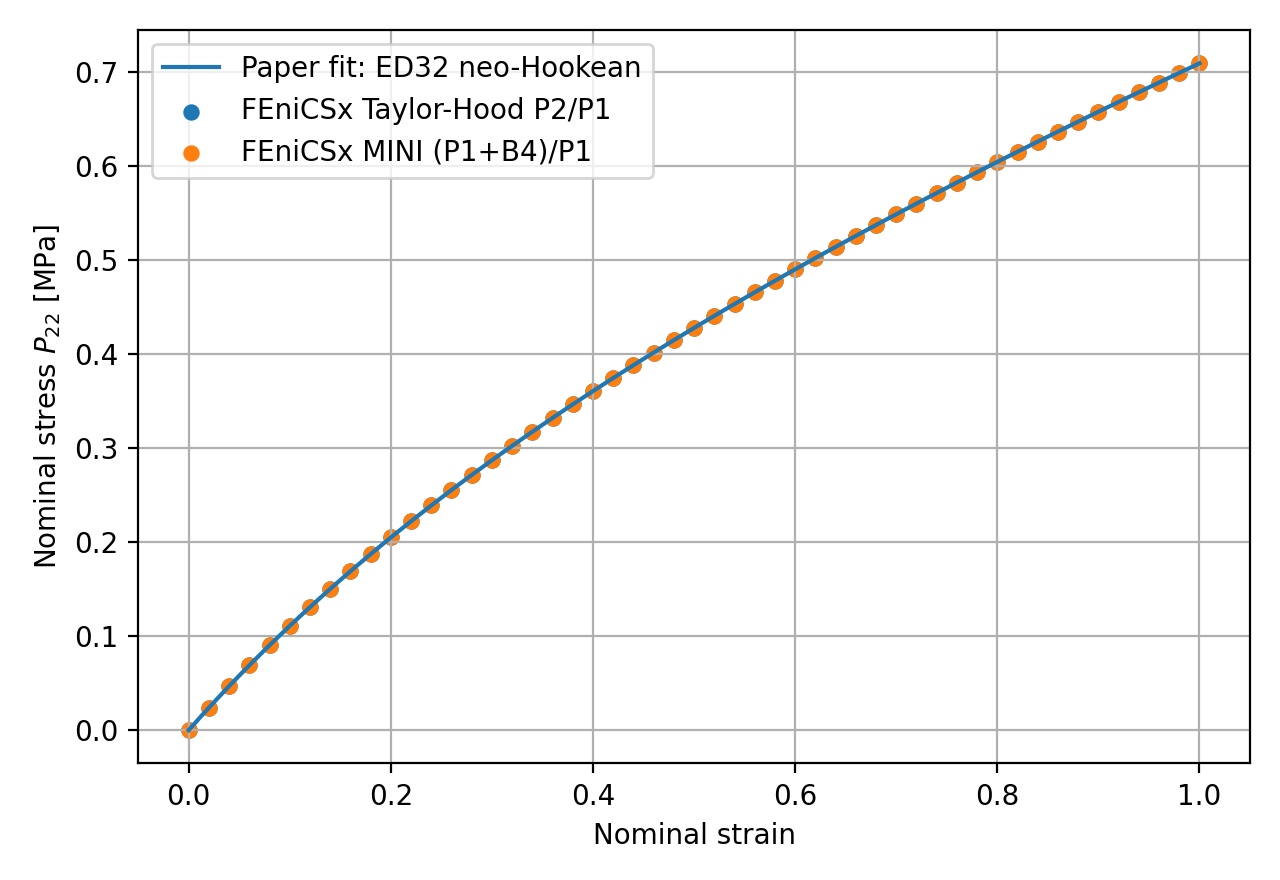

In [6]:
from IPython.display import Image, Markdown, display
lines = ["| Ansatz | Freiheitsgrade | max. Spannungsfehler [MPa] | max. normierter J-Fehler |",
         "|:--|--:|--:|--:|"]
for s in summaries:
    lines.append(f"| {s.formulation} | {s.global_dofs} | {s.max_abs_stress_error:.3e} | {s.max_j_l2:.3e} |")
display(Markdown("\n".join(lines)))
print(f"Referenz bei ε=1: P22={paper_nominal_stress(1.0):.6f} MPa, Reaktion={A0*paper_nominal_stress(1.0):.6f} N")
if plot_path is not None:
    display(Image(filename=str(plot_path)))


## ParaView und Ergebnisdateien

- `ed32_taylor_hood.csv`, `ed32_mini.csv`: je 51 Zustände inklusive Nullzustand, Reaktion, nominale Spannung, Referenzfehler, mittlerer Druck, Inkompressibilitätsfehler und SNES-Iterationen.
- `ed32_paper_reference.csv`: analytische Referenzkurve mit 201 Punkten.
- `ed32_formulation_summary.csv`: Fehlermaße beider Ansätze.
- `ed32_taylorhood_mini_comparison.png`: Vergleich mit dem Paperfit.
- `ed32_taylor_hood.xdmf` und `ed32_mini.xdmf` samt gleichnamiger `.h5`: jeweils 50 Lastzustände mit `displacement_mm` und `pressure_MPa`.

In ParaView die gewünschte `.xdmf` öffnen, **Apply** wählen und **Warp By Vector** mit `displacement_mm` und Faktor 1 anwenden. Die Zeitleiste zeigt die nominale Dehnung. Für Druckdarstellung nach `pressure_MPa` einfärben. XDMF und HDF5 müssen zusammen im selben Ordner bleiben.

Für den Export werden Verschiebung und Druck auf P1-Punktfelder des linearen Netzes interpoliert. Die höhergradigen Verschiebungsanteile werden damit allgemein nicht vollständig dargestellt; beim hier geprüften homogenen affinen Zugzustand ist P1 ausreichend. Die CSV-Auswertung verwendet weiterhin die ursprünglichen FEM-Felder.